In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [2]:
df = pd.read_csv('data\health_markers_dataset.csv')

In [3]:
df.head()

,Blood_glucose,HbA1C,Systolic_BP,Diastolic_BP,LDL,HDL,Triglycerides,Haemoglobin,MCV,Condition
0,107.38,4.93,109.25,74.10,129.20,52.11,68.84,10.17,61.54,Anemia
1,108.65,5.43,92.61,62.02,51.18,44.06,78.82,12.29,91.04,Fit
2,103.95,6.08,122.95,63.01,107.72,52.08,139.58,15.93,81.75,Fit
3,87.33,4.79,91.16,75.81,109.39,46.83,108.29,15.18,85.51,Fit
4,114.42,4.10,122.86,76.11,123.89,52.92,123.22,15.33,92.30,Fit


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Blood_glucose  24838 non-null  float64
 1   HbA1C          24838 non-null  float64
 2   Systolic_BP    24838 non-null  float64
 3   Diastolic_BP   24838 non-null  float64
 4   LDL            24838 non-null  float64
 5   HDL            24838 non-null  float64
 6   Triglycerides  24838 non-null  float64
 7   Haemoglobin    24838 non-null  float64
 8   MCV            24838 non-null  float64
 9   Condition      25000 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.9+ MB


In [5]:
noise_level = {
    "Glucose": 0.05,
    "HbA1c": 0.04,
    "Creatinine": 0.06,
    "Hemoglobin": 0.03,
    "LDL": 0.07,
    "HDL": 0.06,
    "Triglycerides": 0.08,
    "Blood_Pressure": 0.05,
    "BMI": 0.04
}

for col, std in noise_level.items():
    if col in df.columns:
        df[col] = df[col] * np.random.normal(
            loc=1.0,
            scale=std,
            size=len(df)
        )

In [6]:
from numpy.random import rand

unique_conditions = df['Condition'].unique()

flip_prob = 0.12  # 12%

for cond in unique_conditions:
    idx = df[df['Condition'] == cond].index
    flip_idx = idx[rand(len(idx)) < flip_prob]

    other_classes = [c for c in unique_conditions if c != cond]
    df.loc[flip_idx, 'Condition'] = np.random.choice(other_classes, size=len(flip_idx))

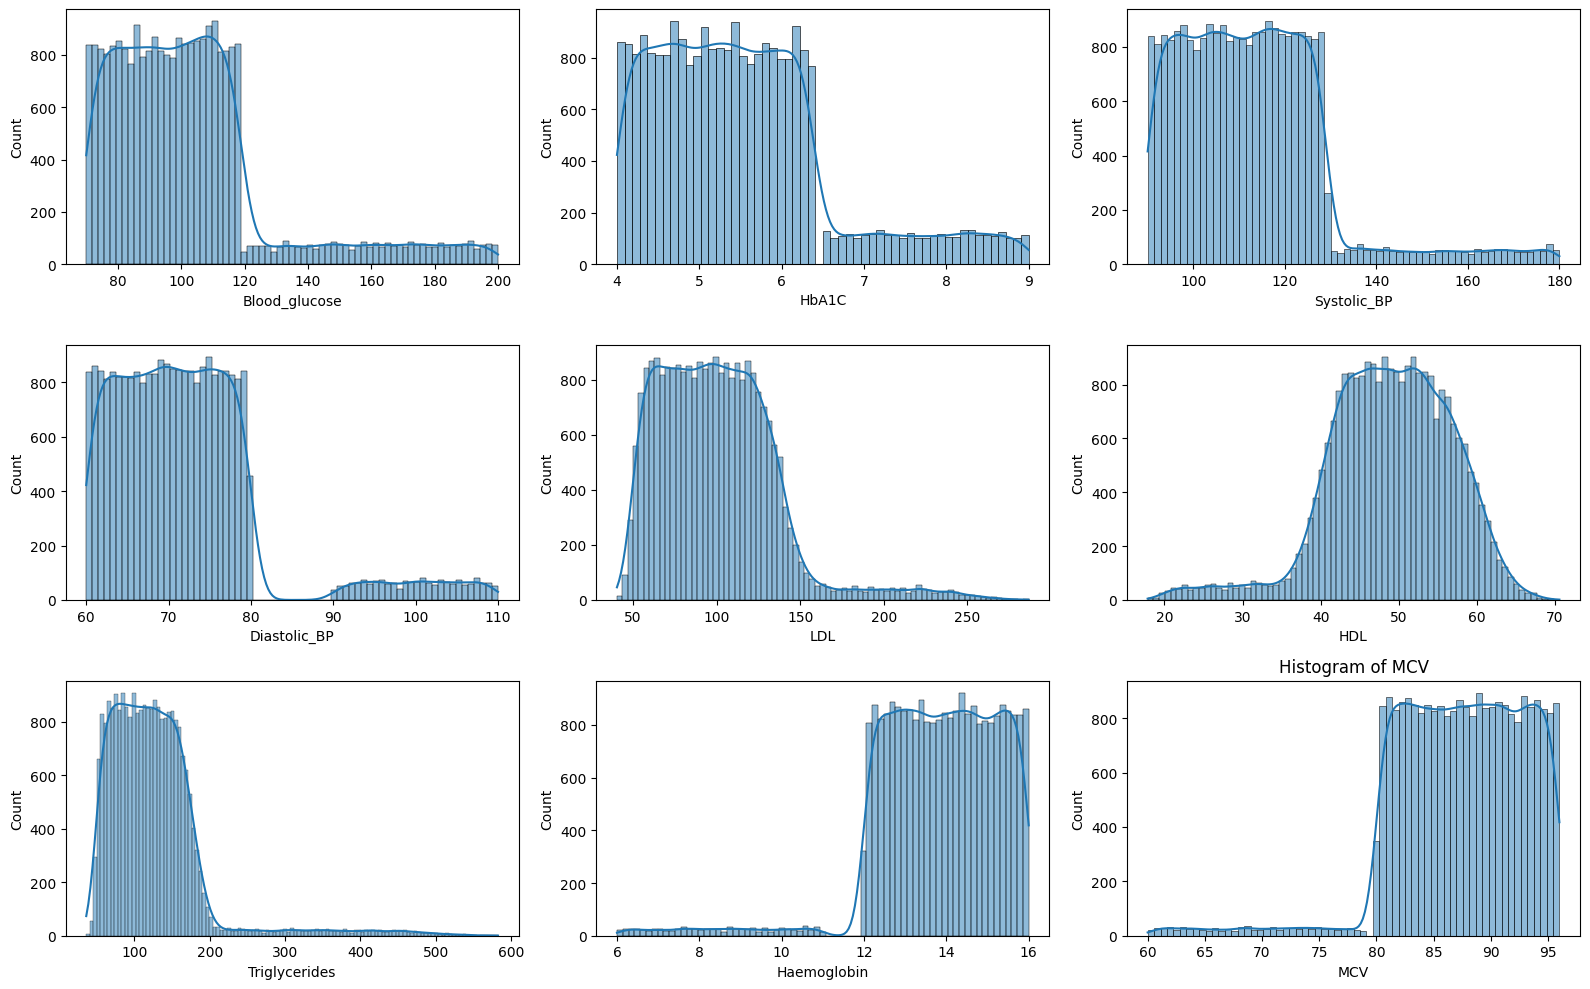

In [7]:
row, cols = 3 , 3
n = 9

fig , axes = plt.subplots(row,cols , figsize=(16 ,10))
axes = axes.flatten()
data_num = df.drop(['Condition']  , axis =1)
for i , col in enumerate(data_num.columns) :
  sns.histplot(data_num[col] , kde = True , ax = axes[i])
  plt.title(f'Histogram of {col}')

# for j in range(n , row*cols) :
#   fig.delaxes(axes[j])

plt.tight_layout()

In [8]:
df.drop('Condition' , axis = 1).corr()

,Blood_glucose,HbA1C,Systolic_BP,Diastolic_BP,LDL,HDL,Triglycerides,Haemoglobin,MCV
Blood_glucose,1.000000,0.621836,-0.058180,-0.071253,-0.049451,0.044406,-0.060033,0.036521,0.032423
HbA1C,0.621836,1.000000,-0.054695,-0.059686,-0.037299,0.034683,-0.051826,0.043524,0.033977
Systolic_BP,-0.058180,-0.054695,1.000000,0.574131,-0.034890,0.026882,-0.039026,0.021137,0.019899
Diastolic_BP,-0.071253,-0.059686,0.574131,1.000000,-0.035916,0.029954,-0.044665,0.021351,0.017975
LDL,-0.049451,-0.037299,-0.034890,-0.035916,1.000000,-0.363578,0.479873,0.012005,0.027515
HDL,0.044406,0.034683,0.026882,0.029954,-0.363578,1.000000,-0.438571,-0.020599,-0.015591
Triglycerides,-0.060033,-0.051826,-0.039026,-0.044665,0.479873,-0.438571,1.000000,0.024694,0.027535
Haemoglobin,0.036521,0.043524,0.021137,0.021351,0.012005,-0.020599,0.024694,1.000000,0.386451
MCV,0.032423,0.033977,0.019899,0.017975,0.027515,-0.015591,0.027535,0.386451,1.000000


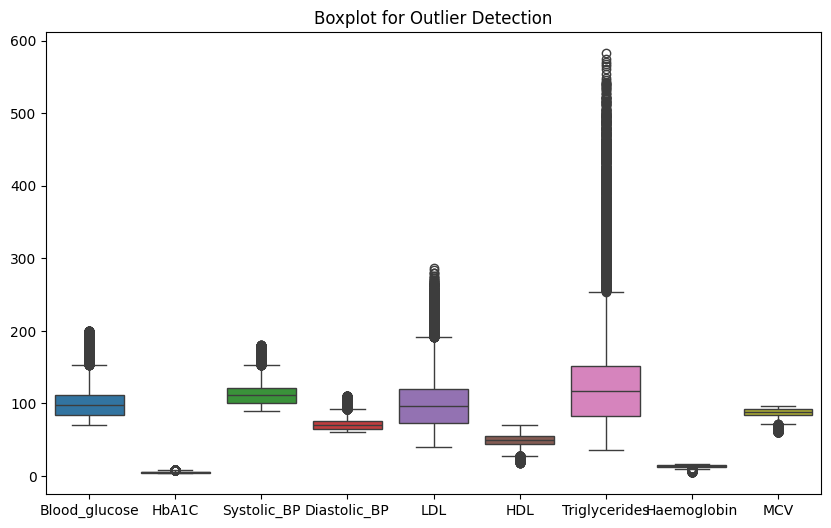

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df)
plt.title('Boxplot for Outlier Detection')
plt.show()

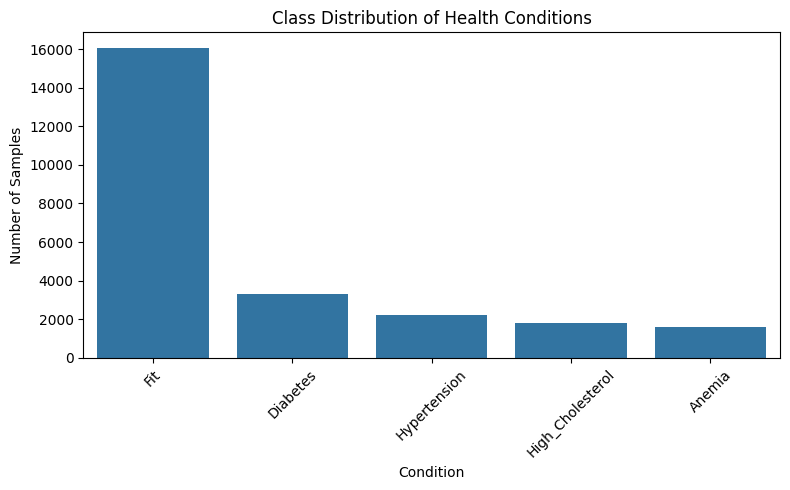

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="Condition",
    order=df["Condition"].value_counts().index
)

plt.title("Class Distribution of Health Conditions")
plt.xlabel("Condition")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

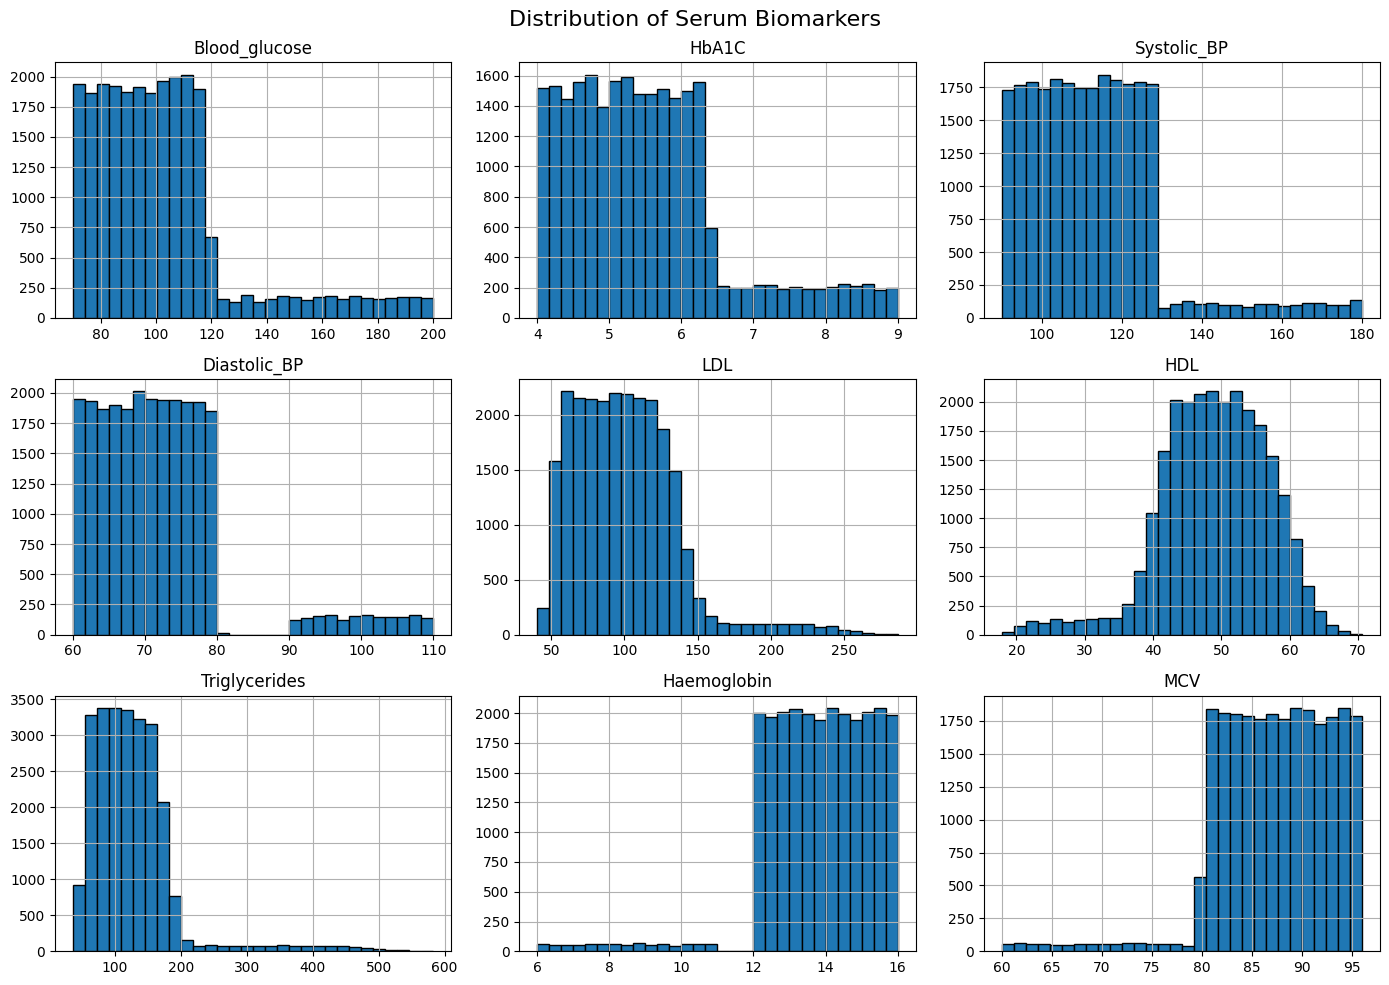

In [11]:
num_features = [
    'Blood_glucose', 'HbA1C', 'Systolic_BP', 'Diastolic_BP',
    'LDL', 'HDL', 'Triglycerides', 'Haemoglobin', 'MCV'
]

df[num_features].hist(
    figsize=(14,10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Serum Biomarkers", fontsize=16)
plt.tight_layout()
plt.show()

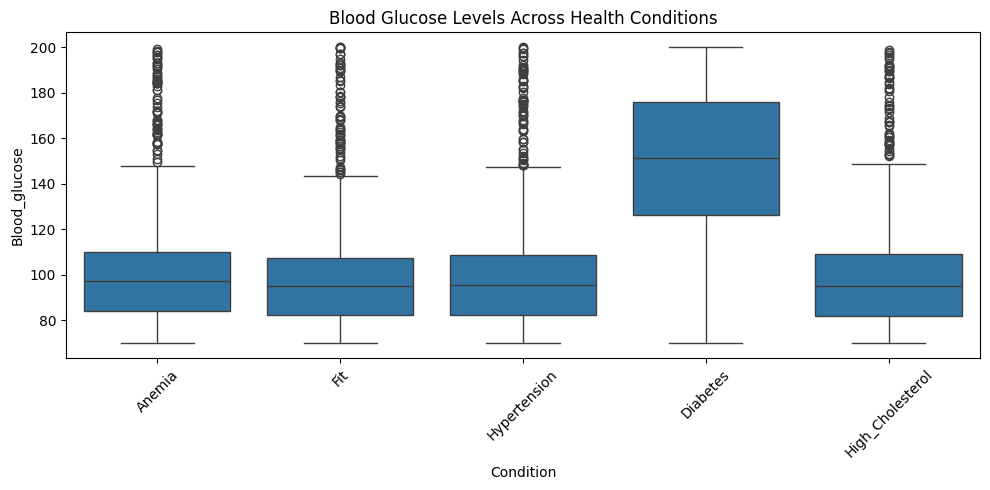

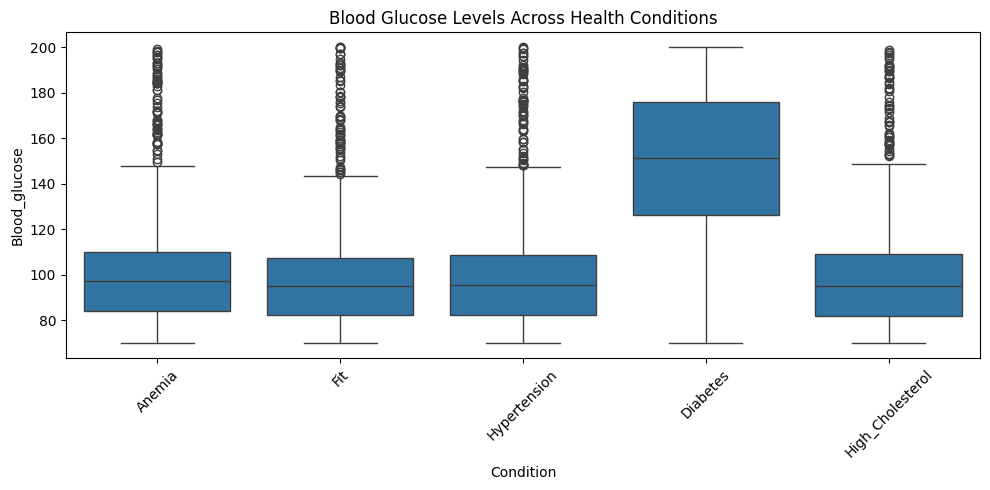

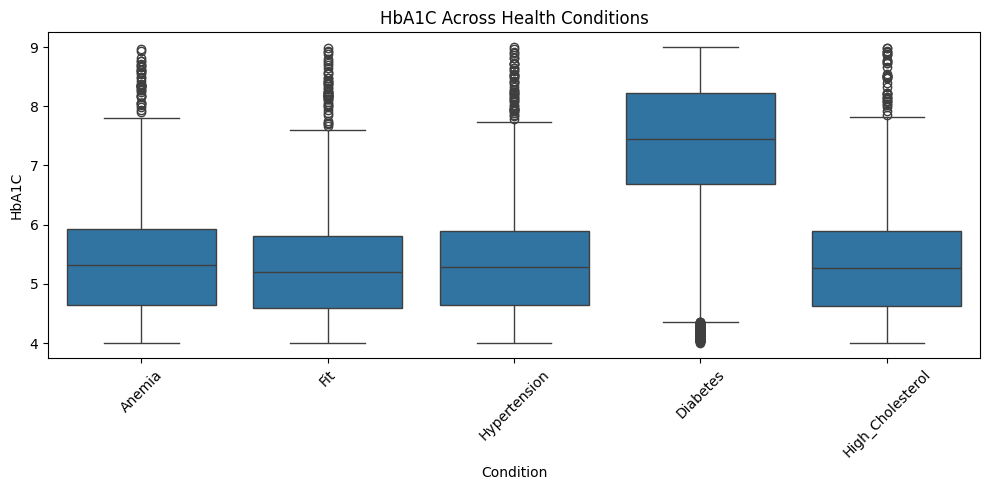

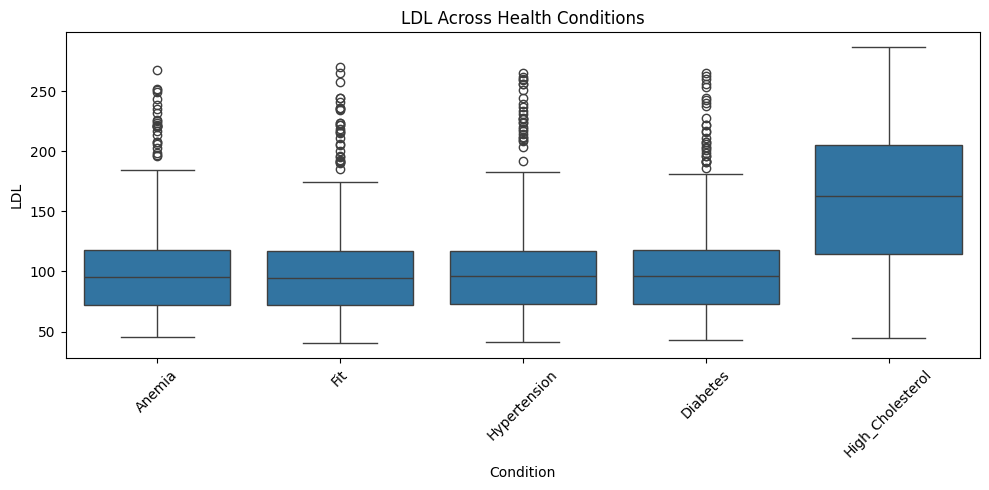

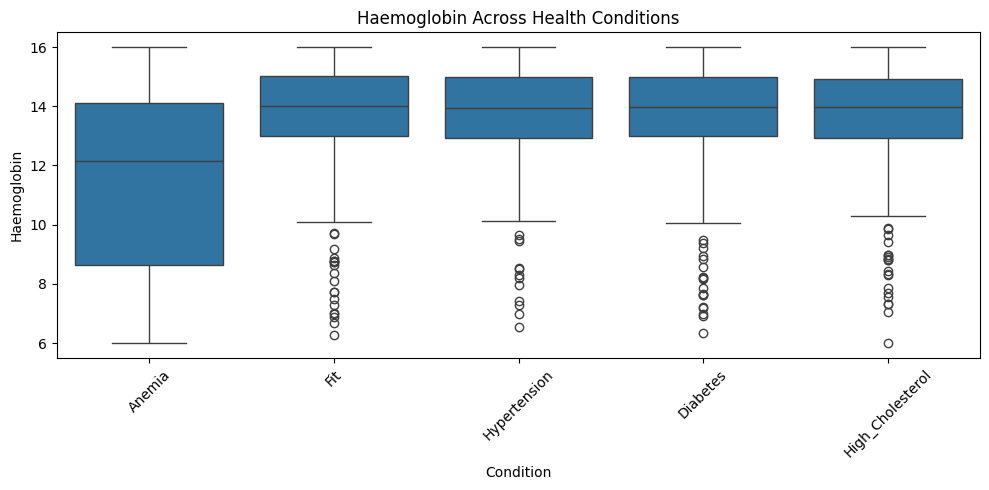

In [16]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=df,
    x="Condition",
    y="Blood_glucose"
)

plt.title("Blood Glucose Levels Across Health Conditions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
for col in ['HbA1C', 'LDL', 'Haemoglobin']:
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df, x="Condition", y=col)
    plt.title(f"{col} Across Health Conditions")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

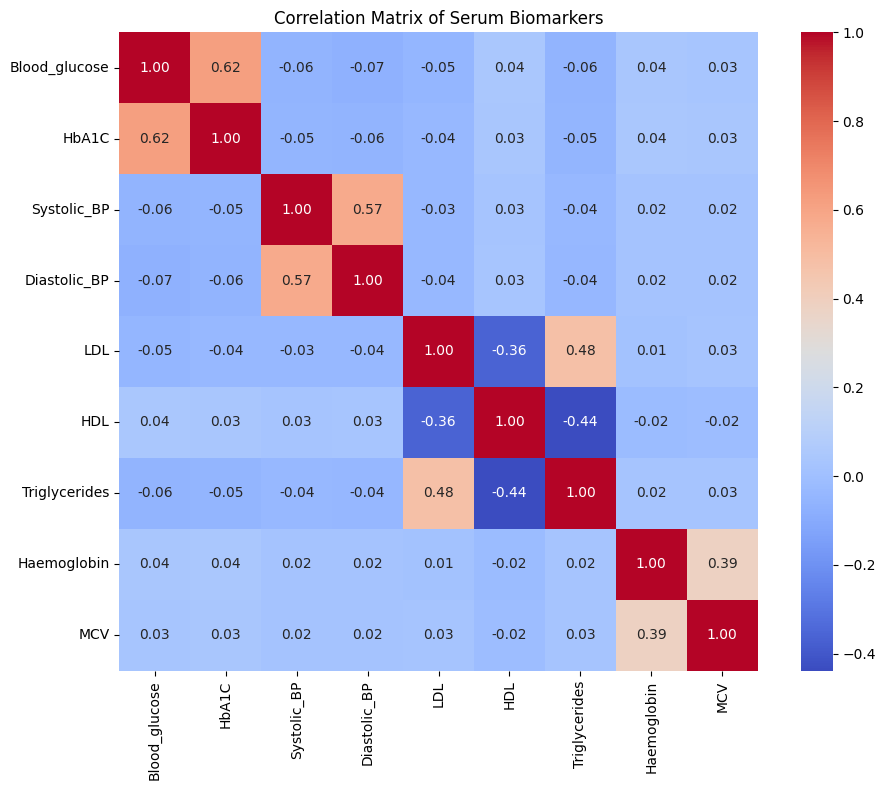

In [14]:
plt.figure(figsize=(10,8))
corr = df[num_features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix of Serum Biomarkers")
plt.tight_layout()
plt.show()

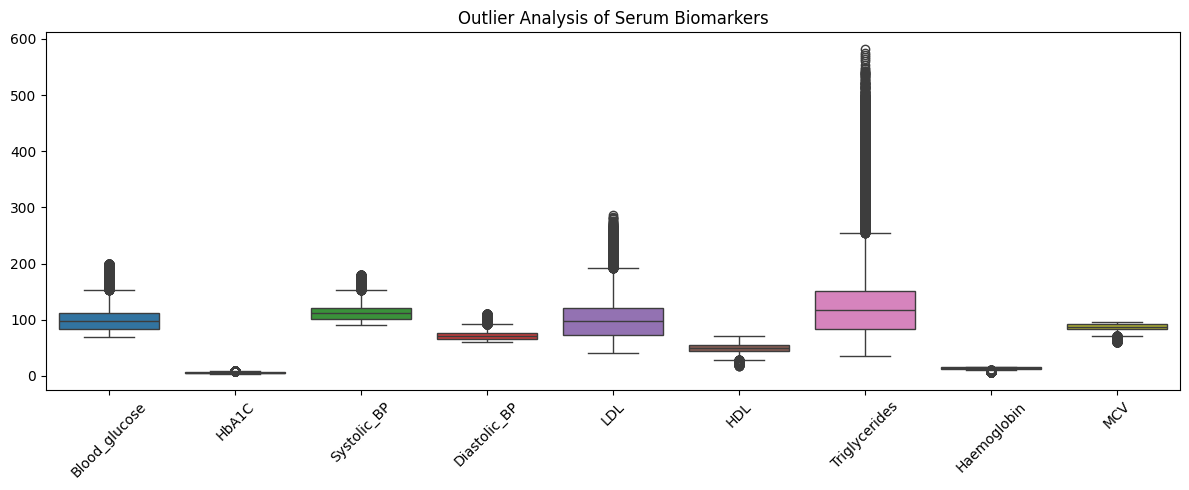

In [15]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df[num_features])
plt.xticks(rotation=45)
plt.title("Outlier Analysis of Serum Biomarkers")
plt.tight_layout()
plt.show()